Companion notebook for *A Probabilistic Mixture Model for Evaluating Sound Localisation Performance in the Median Plane* (Sztandera, Picinali, Barumerli, Forum Acusticum 2026). Run it from the repository root; it reads `data/AXD_measured.csv` (see `data/README.md`).

# AXD Prior Analysis

Applies the extended mixture model (w, κ, κ_prior) to the 33 AXD participants and
examines whether the recovered spatial prior strength (σ_prior_hat) predicts the
polar gain (gainP).

**Hypothesis:** gainP ↑ as σ_prior_hat ↑ — listeners with a stronger horizontal
prior (smaller σ_prior) track target elevations less faithfully.

## Step 0 — Imports and setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import pearsonr, spearmanr

from bayesian_metric import (sigma_to_kappa, kappa_to_sigma,
                             fit_mixture_querr, fit_mixture_with_prior)
from metrics import (
    wrap_polar_angle, accP_cutoff, querrMiddlebrooks,
    rmsPmedianlocal, polar_gain, sirp_regression,
)

# Load AXD data
obs_tbl = pd.read_csv('data/AXD_measured.csv')   # Measured condition only
obs_tbl = obs_tbl[obs_tbl['participant'] != 'P0247'].reset_index(drop=True)

participants = sorted(obs_tbl['participant'].unique())
print(f'{len(participants)} participants, {len(obs_tbl)} trials')

33 participants, 5643 trials


## Step 1 — Extended model functions

Copied from `3_prior_recovery.ipynb` — will migrate to `bayesian_metric.py` once validated.

### Step 1 — Coherence check: polar_gain

In [2]:
# Use a realistic target grid: central targets at various elevations
target_elevs = np.array([0, 15, 30, 45, 60, 75, 90, 120, 150, 180,
                          210, 240, 270, 300, 330, 345])  # degrees
lat_zeros = np.zeros(len(target_elevs))

# Perfect listener: response = target
g_perfect = polar_gain(target_elevs, target_elevs, lat_zeros)
print(f'Perfect listener:  gainP = {g_perfect:.3f}  (expected ~1.0)')

# Flat listener: all responses = 0
g_flat = polar_gain(target_elevs, np.zeros_like(target_elevs), lat_zeros)
print(f'Flat listener:     gainP = {g_flat:.3f}  (expected ~0.0)')

# Reversed listener: response = 180 - target
g_rev = polar_gain(target_elevs, 180 - target_elevs, lat_zeros)
print(f'Reversed listener: gainP = {g_rev:.3f}  (expected ~-1.0)')

Perfect listener:  gainP = 1.000  (expected ~1.0)
Flat listener:     gainP = nan  (expected ~0.0)
Reversed listener: gainP = nan  (expected ~-1.0)


## Step 2 — Fit extended model + compute all metrics for 33 AXD participants

In [3]:
print('Fitting extended model to 33 AXD participants...')

def _fit_participant(pid):
    df = obs_tbl[obs_tbl['participant'] == pid].copy()

    # Arrays for classical metrics (in radians)
    true_hp = np.column_stack([np.deg2rad(df['lat_target'].values),
                                np.deg2rad(df['pol_target'].values)])
    est_hp  = np.column_stack([np.deg2rad(df['lat_response'].values),
                                np.deg2rad(df['pol_response'].values)])

    # Extended model
    ext  = fit_mixture_with_prior(df)
    orig = fit_mixture_querr(df)

    return {
        'participant':      pid,
        'n_trials':         len(df),
        'n_central':        ext['n_trials'],
        # extended model
        'w_hat':            ext['w_hat'],
        'kappa_hat':        ext['kappa_hat'],
        'sigma_hat':        ext['sigma_hat'],
        'kappa_prior_hat':  ext['kappa_prior_hat'],
        'sigma_prior_hat':  ext['sigma_prior_hat'],
        'confusion_pct':    ext['confusion_pct'],
        'nll_ext':          ext['nll'],
        # original model
        'w_hat_orig':       orig['w_hat'],
        'sigma_hat_orig':   orig['sigma_hat'],
        'nll_orig':         orig['nll'],
        # classical metrics
        'accP_deg':         np.rad2deg(accP_cutoff(true_hp, est_hp)[0]),
        'querr_pct':        querrMiddlebrooks(true_hp, est_hp)[0],
        'rmsPlocal_deg':    np.rad2deg(rmsPmedianlocal(true_hp, est_hp)[0]),
        # polar gain
        'gainP':            polar_gain(df['pol_target'].values,
                                       df['pol_response'].values,
                                       df['lat_target'].values),
    }

results = joblib.Parallel(n_jobs=-1, prefer='threads')(
    joblib.delayed(_fit_participant)(pid) for pid in participants
)

metrics_df = pd.DataFrame(results).set_index('participant')
print('Done.')


Fitting extended model to 33 AXD participants...


Done.


In [4]:
print(metrics_df[['n_central','gainP', 'sigma_hat', 'sigma_prior_hat', 'confusion_pct',
                   'querr_pct', 'rmsPlocal_deg']].round(2).to_string())

             n_central  gainP  sigma_hat  sigma_prior_hat  confusion_pct  querr_pct  rmsPlocal_deg
participant                                                                                       
P0001              123   0.32      43.78            31.45           2.70       7.21          34.49
P0003               33   0.42      43.26            35.47           0.00       9.38          30.53
P0005               45   0.33      42.08            19.47          25.72      29.41          42.77
P0006              123   0.36      50.86            34.40           3.74      11.11          37.03
P0015               78   0.37      30.51            21.22           6.02       6.35          36.49
P0019               78   0.81      30.10            60.34          16.81      15.94          27.31
P0020               45   0.65      38.57            28.95          11.44      10.81          28.68
P0031               78   0.75      35.02            53.35           9.40       7.35          36.82
P0043     

## Step 3 — Main result: gainP vs σ_prior_hat

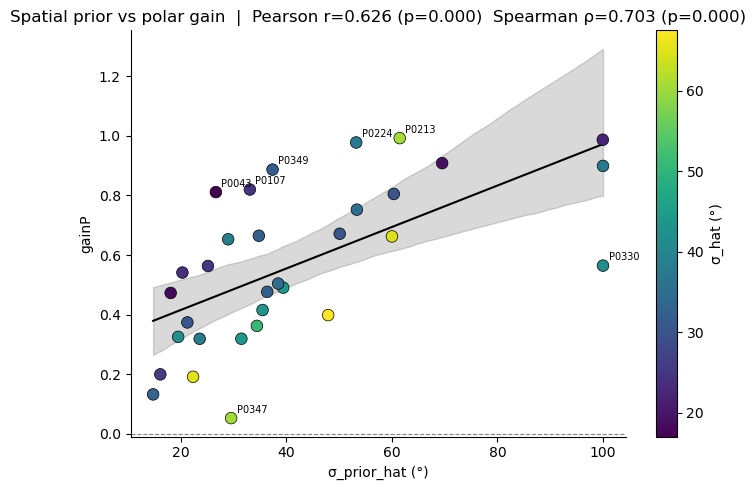

Pearson  r = 0.626  (p = 0.0001)
Spearman ρ = 0.703  (p = 0.0000)
Regression slope: 0.0070  intercept: 0.2770


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

mask = np.isfinite(metrics_df['gainP']) & np.isfinite(metrics_df['sigma_prior_hat'])
x = metrics_df.loc[mask, 'sigma_prior_hat'].values
y = metrics_df.loc[mask, 'gainP'].values
c = metrics_df.loc[mask, 'sigma_hat'].values

sc = ax.scatter(x, y, c=c, cmap='viridis', s=70, edgecolors='k', linewidths=0.5, zorder=3)
plt.colorbar(sc, ax=ax, label='σ_hat (°)')

# Regression line + 95% CI
p = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = np.polyval(p, x_line)
ax.plot(x_line, y_line, 'k-', lw=1.5, zorder=2)

# 95% CI via bootstrap
rng_boot = np.random.default_rng(42)
n = len(x)
boots = np.array([
    np.polyval(np.polyfit(x[idx], y[idx], 1), x_line)
    for idx in (rng_boot.integers(0, n, size=(1000, n)))
])
ax.fill_between(x_line,
                np.percentile(boots, 2.5, axis=0),
                np.percentile(boots, 97.5, axis=0),
                alpha=0.15, color='k', zorder=1)

# Annotate outliers (residual > 1.5 IQR)
resid = y - np.polyval(p, x)
iqr = np.percentile(np.abs(resid), 75) - np.percentile(np.abs(resid), 25)
outlier_mask = np.abs(resid) > 1.5 * iqr
pids = metrics_df.index[mask].values
for i, pid in enumerate(pids):
    if outlier_mask[i]:
        ax.annotate(pid, (x[i], y[i]), fontsize=7,
                    xytext=(4, 4), textcoords='offset points')

r_p, pval_p = pearsonr(x, y)
r_s, pval_s = spearmanr(x, y)

ax.set_xlabel('σ_prior_hat (°)')
ax.set_ylabel('gainP')
ax.set_title(f'Spatial prior vs polar gain  |  '
             f'Pearson r={r_p:.3f} (p={pval_p:.3f})  '
             f'Spearman ρ={r_s:.3f} (p={pval_s:.3f})')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Pearson  r = {r_p:.3f}  (p = {pval_p:.4f})')
print(f'Spearman ρ = {r_s:.3f}  (p = {pval_s:.4f})')
print(f'Regression slope: {p[0]:.4f}  intercept: {p[1]:.4f}')

## Step 4 — Extended model parameters vs classical metrics

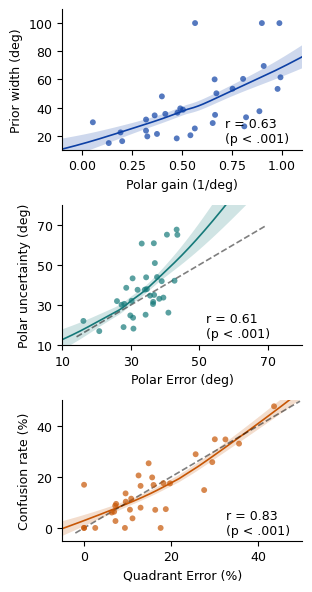

In [6]:
plt.rcParams.update({'font.size': 9})
fig, axes = plt.subplots(3, 1, figsize=(3.19, 6))

panels = [
    ('gainP',          'sigma_prior_hat',  'Polar gain (1/deg)', 'Prior width (deg)',     [-.1, 1.1],  [10, 110], '#0d40a5'),
    ('rmsPlocal_deg',  'sigma_hat',        'Polar Error (deg)',             'Polar uncertainty (deg)', [10, 80],[10, 80], '#157979'),
    ('querr_pct',      'confusion_pct',    'Quadrant Error (%)',             'Confusion rate (%)',    [-5, 50], [-5, 50], '#c75605'),
]

def loess(x, y, x_eval, frac=1):
    """LOESS with tricube weights. Returns (y_smooth, se) where se is the
    pointwise standard error from the weighted residuals of each local fit."""
    n = len(x)
    h = max(int(np.ceil(frac * n)), 3)
    y_smooth = np.empty(len(x_eval))
    se       = np.empty(len(x_eval))
    for i, xi in enumerate(x_eval):
        dists   = np.abs(x - xi)
        nn_idx  = np.argsort(dists)[:h]
        d_max   = dists[nn_idx[-1]]
        u       = dists[nn_idx] / (d_max + 1e-12)
        w       = np.clip(1 - u**3, 0, None) ** 3
        A       = np.column_stack([np.ones(h), x[nn_idx]])
        b, _, _, _ = np.linalg.lstsq(A * w[:, None], y[nn_idx] * w, rcond=None)
        y_smooth[i] = b[0] + b[1] * xi
        # Weighted MSE from local residuals
        resid = y[nn_idx] - (A @ b)
        mse   = np.sum(w * resid**2) / max(h - 2, 1)
        # Variance of fitted value at xi: x_i^T (A^T W A)^{-1} x_i * mse
        AtWA  = A.T @ (A * w[:, None])
        xi_v  = np.array([1.0, xi])
        try:
            var_fit = mse * xi_v @ np.linalg.inv(AtWA) @ xi_v
        except np.linalg.LinAlgError:
            var_fit = np.nan
        se[i] = np.sqrt(np.abs(var_fit))
    return y_smooth, se

for ax, (xc, yc, xl, yl, xlim, ylim, color) in zip(axes.flat, panels):
    m = np.isfinite(metrics_df[xc]) & np.isfinite(metrics_df[yc])
    xv = metrics_df.loc[m, xc].values
    yv = metrics_df.loc[m, yc].values

    ax.scatter(xv, yv, s=18, color = color, edgecolors='None', alpha =.7, linewidths=0.5, zorder=3)

    xl_line = np.linspace(xlim[0], xlim[1], 200)
    y_line, y_se = loess(xv, yv, xl_line)

    ax.fill_between(xl_line, y_line - y_se, y_line + y_se,
                    alpha=0.2, color=color, zorder=1, edgecolors='None')
    ax.plot(xl_line, y_line, '-', color=color, lw=1.2, zorder=2)

    lims = [min(xv.min(), yv.min()) - 2, max(xv.max(), yv.max()) + 2]
    ax.plot(lims, lims, 'k--', lw=1.2, alpha=0.5)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    if yc == 'sigma_hat':
        ax.set_xticks(np.arange(xlim[0], xlim[1] + 1, 20))
        ax.set_yticks(np.arange(ylim[0], ylim[1] + 1, 20))

    if yc == 'confusion_pct':
        ax.set_xticks(np.arange(0, xlim[1] + 1, 20))
        ax.set_yticks(np.arange(0, ylim[1] + 1, 20))
    r, pv = pearsonr(xv, yv)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.text(xlim[1]*.65, ylim[0]+ylim[1]*.05, f'r = {r:.2f}\n(p < .001)')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/fig_params_vs_classical.png', dpi=300, bbox_inches='tight')
plt.show()

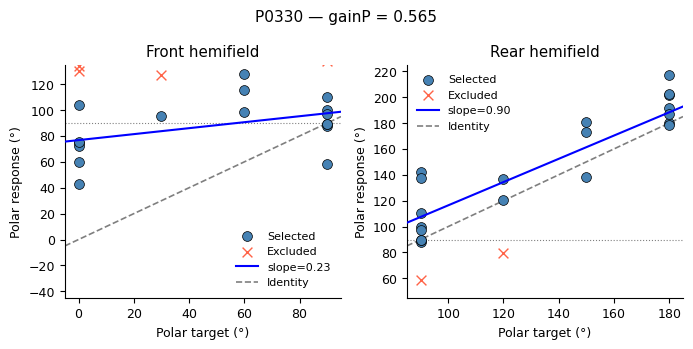

In [7]:
# Diagnostic: pol_target vs pol_response for P0330 (gainP scatter)
PID = 'P0330'
df_p = obs_tbl[
    (obs_tbl['participant'] == PID) &
    (np.abs(obs_tbl['lat_target']) <= 30.0)
].copy()

pol_t = df_p['pol_target'].values
pol_r = df_p['pol_response'].values

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))

for ax, (label, front, xlim, ylim) in zip(axes, [
    ('Front', True,  [-5, 95],  [-45, 135]),
    ('Rear',  False, [85, 185], [45, 225]),
]):
    # SIRP pool: every response to a target in this hemifield (M&M 2003)
    in_pool = (pol_t <= 90.0) if front else (pol_t >= 90.0)
    x = pol_t[in_pool]
    y = pol_r[in_pool]

    slope, intercept, inliers = sirp_regression(pol_t, pol_r, front=front)

    if np.isnan(slope):
        ax.set_title(f'{label} — insufficient data')
        continue

    ax.scatter(x[inliers],  y[inliers],  s=50, color='steelblue',
               edgecolors='k', linewidths=0.5, zorder=3, label='Selected')
    ax.scatter(x[~inliers], y[~inliers], s=50, color='tomato',
               linewidths=1.0, zorder=3, label='Excluded', marker='x')
    ax.axhline(90.0, color='gray', lw=0.8, ls=':', zorder=1)

    xl_line = np.linspace(xlim[0], xlim[1], 100)
    ax.plot(xl_line, slope * xl_line + intercept,
            'b-', lw=1.5, zorder=4, label=f'slope={slope:.2f}')

    ax.plot(xlim, xlim, 'k--', lw=1.2, alpha=0.5, label='Identity')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('Polar target (°)')
    ax.set_ylabel('Polar response (°)')
    ax.set_title(f'{label} hemifield')
    ax.legend(fontsize=8, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

gainP_val = metrics_df.loc[PID, 'gainP']
fig.suptitle(f'{PID} — gainP = {gainP_val:.3f}', fontsize=11)
plt.tight_layout()
plt.show()

## Step 5 — Does the original model confound σ when the prior is present?

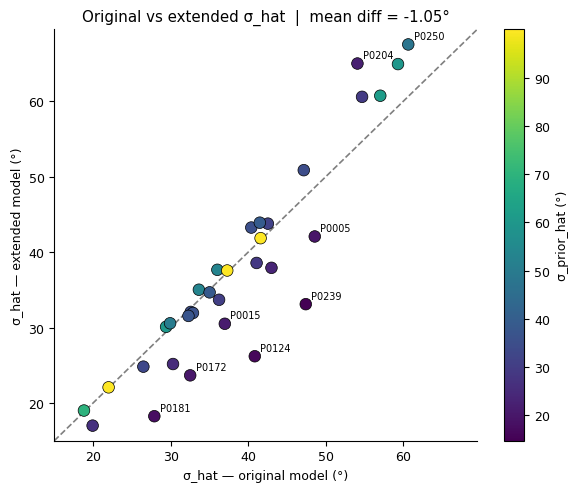

Mean (extended − original) σ_hat: -1.05°
(positive = extended model gives larger σ)


In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

m = np.isfinite(metrics_df['sigma_hat_orig']) & np.isfinite(metrics_df['sigma_hat'])
xv = metrics_df.loc[m, 'sigma_hat_orig'].values
yv = metrics_df.loc[m, 'sigma_hat'].values
cv = metrics_df.loc[m, 'sigma_prior_hat'].values

sc = ax.scatter(xv, yv, c=cv, cmap='viridis', s=70,
                edgecolors='k', linewidths=0.5, zorder=3)
plt.colorbar(sc, ax=ax, label='σ_prior_hat (°)')

lims = [min(xv.min(), yv.min()) - 2, max(xv.max(), yv.max()) + 2]
ax.plot(lims, lims, 'k--', lw=1.2, alpha=0.5, label='identity')

# Annotate participants where difference is large
diff = yv - xv
big = np.abs(diff) > np.percentile(np.abs(diff), 75)
pids = metrics_df.index[m].values
for i, pid in enumerate(pids):
    if big[i]:
        ax.annotate(pid, (xv[i], yv[i]), fontsize=7,
                    xytext=(4, 4), textcoords='offset points')

mean_diff = np.mean(diff)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('σ_hat — original model (°)')
ax.set_ylabel('σ_hat — extended model (°)')
ax.set_title(f'Original vs extended σ_hat  |  '
             f'mean diff = {mean_diff:+.2f}°')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Mean (extended − original) σ_hat: {mean_diff:+.2f}°')
print(f'(positive = extended model gives larger σ)')

## Step 5b — BIC model comparison

BIC = k·ln(n) − 2·ln(L̂), where k = number of free parameters and n = number of trials.
Original model: k=2 (w, κ). Extended model: k=3 (w, κ, κ_prior).
ΔBIC = BIC_extended − BIC_original; negative values favour the extended model.

ΔBIC (extended − original):
  Mean  = -34.09
  Median = -23.80
  Range  = [-140.65, +4.43]

Participants favouring extended model (ΔBIC < −2): 26/33
Participants favouring original model (ΔBIC > +2): 4/33
Ambiguous (|ΔBIC| ≤ 2):                           3/33


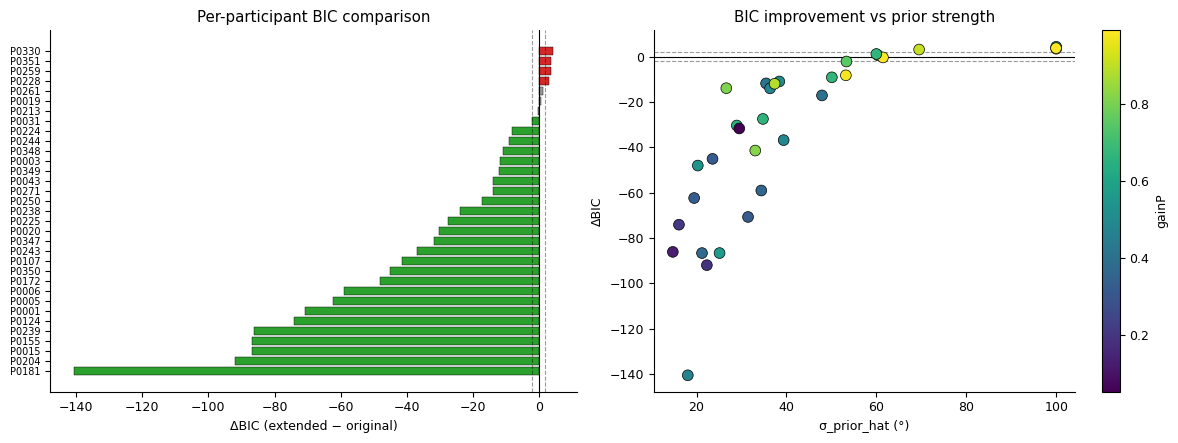


             n_central  nll_orig  nll_ext  bic_orig  bic_ext  delta_bic  sigma_prior_hat
participant                                                                             
P0181              123    132.83    60.10    275.28   134.64    -140.65            18.06
P0204               78    114.35    66.16    237.41   145.39     -92.01            22.30
P0015               78     89.36    43.85    187.44   100.77     -86.67            21.22
P0155              123    152.98   107.24    315.59   228.93     -86.67            25.12
P0239               45     73.29    28.31    154.19    68.03     -86.16            14.72
P0124               45     61.81    22.84    131.24    57.10     -74.14            16.09
P0001              123    147.36   109.59    304.34   233.61     -70.73            31.45
P0005               45     71.05    37.97    149.72    87.36     -62.36            19.47
P0006              123    163.84   131.92    337.31   278.27     -59.04            34.40
P0172               

In [9]:
k_orig = 2   # w, kappa
k_ext  = 3   # w, kappa, kappa_prior

n = metrics_df['n_central'].values
nll_orig = metrics_df['nll_orig'].values
nll_ext  = metrics_df['nll_ext'].values

bic_orig = k_orig * np.log(n) + 2 * nll_orig
bic_ext  = k_ext  * np.log(n) + 2 * nll_ext
delta_bic = bic_ext - bic_orig

metrics_df['bic_orig'] = bic_orig
metrics_df['bic_ext']  = bic_ext
metrics_df['delta_bic'] = delta_bic

n_favour_ext  = (delta_bic < -2).sum()    # "positive" evidence for extended
n_favour_orig = (delta_bic >  2).sum()    # "positive" evidence for original
n_ambiguous   = ((delta_bic >= -2) & (delta_bic <= 2)).sum()

print(f'ΔBIC (extended − original):')
print(f'  Mean  = {delta_bic.mean():+.2f}')
print(f'  Median = {np.median(delta_bic):+.2f}')
print(f'  Range  = [{delta_bic.min():+.2f}, {delta_bic.max():+.2f}]')
print()
print(f'Participants favouring extended model (ΔBIC < −2): {n_favour_ext}/{len(delta_bic)}')
print(f'Participants favouring original model (ΔBIC > +2): {n_favour_orig}/{len(delta_bic)}')
print(f'Ambiguous (|ΔBIC| ≤ 2):                           {n_ambiguous}/{len(delta_bic)}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel 1: ΔBIC per participant
order = np.argsort(delta_bic)
colors = ['#2ca02c' if d < -2 else '#d62728' if d > 2 else '#999999' for d in delta_bic[order]]
axes[0].barh(range(len(order)), delta_bic[order], color=colors, edgecolor='k', linewidth=0.3)
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels(metrics_df.index[order], fontsize=7)
axes[0].axvline(0, color='k', lw=0.8)
axes[0].axvline(-2, color='k', lw=0.8, ls='--', alpha=0.4)
axes[0].axvline(2, color='k', lw=0.8, ls='--', alpha=0.4)
axes[0].set_xlabel('ΔBIC (extended − original)')
axes[0].set_title('Per-participant BIC comparison')
axes[0].spines[['top', 'right']].set_visible(False)

# Panel 2: ΔBIC vs σ_prior_hat
mask = np.isfinite(metrics_df['sigma_prior_hat'])
axes[1].scatter(metrics_df.loc[mask, 'sigma_prior_hat'], delta_bic[mask],
                c=metrics_df.loc[mask, 'gainP'], cmap='viridis',
                s=60, edgecolors='k', linewidths=0.5, zorder=3)
cb = plt.colorbar(axes[1].collections[0], ax=axes[1], label='gainP')
axes[1].axhline(0, color='k', lw=0.8)
axes[1].axhline(-2, color='k', lw=0.8, ls='--', alpha=0.4)
axes[1].axhline(2, color='k', lw=0.8, ls='--', alpha=0.4)
axes[1].set_xlabel('σ_prior_hat (°)')
axes[1].set_ylabel('ΔBIC')
axes[1].set_title('BIC improvement vs prior strength')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Summary table
bic_tbl = metrics_df[['n_central', 'nll_orig', 'nll_ext', 'bic_orig', 'bic_ext',
                       'delta_bic', 'sigma_prior_hat']].sort_values('delta_bic')
print('\n' + bic_tbl.round(2).to_string())

## Step 6 — Summary table

In [10]:
summary = metrics_df[[
    'gainP', 'w_hat', 'sigma_hat', 'sigma_prior_hat',
    'confusion_pct', 'querr_pct', 'rmsPlocal_deg',
]].copy().sort_values('sigma_prior_hat')

print(summary.round(2).to_string())

# Overall correlations with gainP
print('\nCorrelations with gainP:')
for col in ['sigma_prior_hat', 'sigma_hat', 'w_hat', 'querr_pct', 'rmsPlocal_deg']:
    m = np.isfinite(metrics_df[col]) & np.isfinite(metrics_df['gainP'])
    r_p, p_p = pearsonr(metrics_df.loc[m, col], metrics_df.loc[m, 'gainP'])
    r_s, p_s = spearmanr(metrics_df.loc[m, col], metrics_df.loc[m, 'gainP'])
    print(f'  {col:20s}  Pearson r={r_p:+.3f} (p={p_p:.3f})  '
          f'Spearman ρ={r_s:+.3f} (p={p_s:.3f})')

             gainP  w_hat  sigma_hat  sigma_prior_hat  confusion_pct  querr_pct  rmsPlocal_deg
participant                                                                                   
P0239         0.13   0.67      33.11            14.72          32.95      35.56          38.33
P0124         0.20   0.84      26.21            16.09          16.44      12.96          40.99
P0181         0.47   0.79      18.26            18.06          20.51      12.50          30.78
P0005         0.33   0.74      42.08            19.47          25.72      29.41          42.77
P0172         0.54   1.00      23.67            20.28           0.01       0.00          30.67
P0015         0.37   0.94      30.51            21.22           6.02       6.35          36.49
P0204         0.19   1.00      64.99            22.30           0.00      17.57          40.56
P0350         0.32   0.93      37.92            23.55           7.07      16.33          34.70
P0155         0.56   0.71      25.17            25

In [11]:
# Summary table: two-parameter vs three-parameter model
def fmt(series):
    return f'{series.mean():.1f} ± {series.std()/np.sqrt(series.count()):.1f}'

n = len(metrics_df)
conf_orig   = (1 - metrics_df['w_hat_orig']) * 100
conf_ext    = metrics_df['confusion_pct']
n_favour_ext  = (metrics_df['delta_bic'] < -2).sum()
n_favour_orig = (metrics_df['delta_bic'] >  2).sum()

rows = {
    'Model':              ['Two-parameter',                        'Three-parameter'],
    'Confusion 1−w (%)':  [fmt(conf_orig),                        fmt(conf_ext)],
    'σ (°)':              [fmt(metrics_df['sigma_hat_orig']),      fmt(metrics_df['sigma_hat'])],
    'σ_prior (°)':        ['—',                                    fmt(metrics_df['sigma_prior_hat'])],
    'ΔBIC':               ['ref',                                  fmt(metrics_df['delta_bic'])],
    'Listeners favoured': [f'{n_favour_orig}/{n} ({100*n_favour_orig/n:.0f}%)',
                           f'{n_favour_ext}/{n} ({100*n_favour_ext/n:.0f}%)'],
}

table = pd.DataFrame(rows).set_index('Model')
table.to_clipboard()